# 4. Simulación de las temperaturas de la celda 01.
## Importación y carga de datos
En esta sección se importarán los datos y librerías necesarias para el análisis del apartado 4.

In [2]:
from carga_de_datos import *

Tamaño de df_orig_temp con los datos cargados: (4383, 15)
Dataframe con todos los datos leidos (filas: días, columnas: variables):
           FECHA  TEMP_CELDA01  TEMP_CELDA02  TEMP_CELDA03  TEMP_CELDA04  \
0     2014-01-01      9.304810      9.234131      9.134725      8.917480   
1     2014-01-02     11.986209     11.888858     11.768883     11.706729   
2     2014-01-03     13.474006     13.405910     13.308051     13.187058   
3     2014-01-04     11.460185     11.400940     11.306010     11.271545   
4     2014-01-05      7.990672      8.004791      7.974009      7.590749   
...          ...           ...           ...           ...           ...   
4378  2025-12-27      6.853189      6.883666      6.892943      6.586832   
4379  2025-12-28      8.640758      8.662160      8.675710      8.074249   
4380  2025-12-29      7.409761      7.522859      7.593782      6.951753   
4381  2025-12-30      8.605798      8.644759      8.652287      7.629785   
4382  2025-12-31      7.655819   

## 4.1. Simulación con las distribuciones elegidas en el punto 2.2
### Pregunta
A partir de las distribuciones elegidas en el punto 2.2 (irradiación, temperatura y precipitación de la celda 01), y de forma independiente, generar cuatro muestras de números pseudoaleatorios de tamaño n1 = 10, n2 = 100, n3 = 1000 y n4 = 10000 para cada variable.
Para cada variable y cada tamaño muestral, representar en una misma gráfica las distribuciones de la muestra simulada y de los datos reales, y discutir qué se observa conforme aumenta el tamaño de la muestra.

In [ ]:
# He creado una función para no tener que escribir el código de mostrar la gráfica 4 veces por subapartado

def plot_histogramas(x_real, VA, x1, x2, x3, x4, nombre_variable):
    fig = plt.figure(figsize=(14, 10))

    muestras = [x1, x2, x3, x4]
    tamaños = [10, 100, 1000, 10000]

    for i in range(4):
        plt.subplot(2, 2, i + 1)

        x_sim = muestras[i]
        n = tamaños[i]

        xmin = min(np.min(x_real), np.min(x_sim))
        xmax = max(np.max(x_real), np.max(x_sim))
        margen = 0.05 * (xmax - xmin) if xmax > xmin else 1
        xs = np.linspace(xmin - margen, xmax + margen, 1000)

        plt.hist(x_real, bins=30, density=True, alpha=0.6,
                 label='Datos reales', color='steelblue',
                 edgecolor='black', linewidth=0.5)

        plt.hist(x_sim, bins=30, density=True, alpha=0.5,
                 label=f'Simulación (n={n})', color='coral',
                 edgecolor='black', linewidth=0.5)

        plt.plot(xs, VA.pdf(xs), 'g-', linewidth=2.5,
                 label='Función de densidad teórica')

        plt.title(f'{nombre_variable} - Tamaño de muestra: n = {n}',
                  fontsize=11, fontweight='bold')
        plt.xlabel('Valor')
        plt.ylabel('Densidad')
        plt.legend(fontsize=9)
        plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# He puesto las n's aqui por que se usan en todos los apartados de forma fija

n1 = 10
n2 = 100
n3 = 1000
n4 = 10000

Parámetros temperatura (triangular): (np.float64(0.2852643846843769), np.float64(1.7239338685154788), np.float64(36.831829557286525))


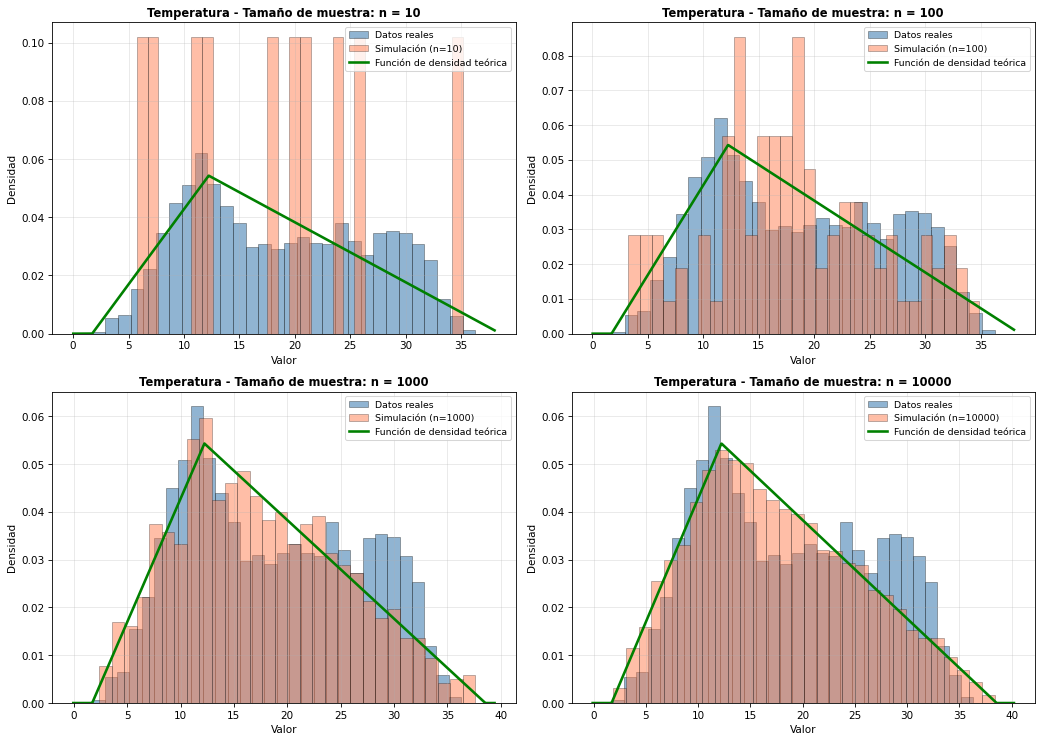

In [24]:
#Temperatura

from carga_de_datos import *
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

semilla = 99999
np.random.seed(semilla)

x_real = df_orig_temp["TEMP_CELDA01"].dropna().values

#Cogemos la triangular del apartado 2.2
params = stats.triang.fit(x_real)

c = params[0]
loc = params[1]
scale = params[2]
VA = stats.triang(c=c, loc=loc, scale=scale)

print("Parámetros temperatura (triangular):", params)

x1 = VA.rvs(size=n1)
x2 = VA.rvs(size=n2)
x3 = VA.rvs(size=n3)
x4 = VA.rvs(size=n4)

plot_histogramas(x_real, VA, x1, x2, x3, x4, "Temperatura")

Parámetros irradiación (triangular): (np.float64(0.9640841834647736), np.float64(-110483.64769757228), np.float64(1420888.0004384872))


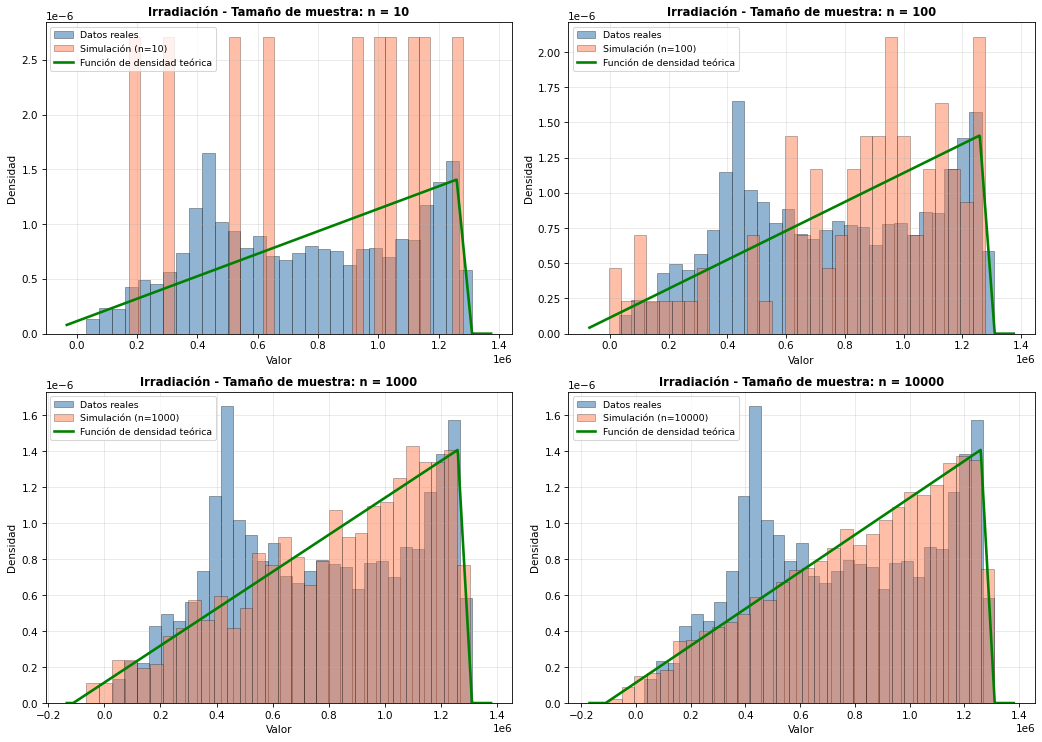

In [16]:
#Irradiación

semilla = 99999
np.random.seed(semilla)

x_real = df_orig_irrad["IRRAD_CELDA01"].dropna().values

#Cogemos la triangular del apartado 2.2
params = stats.triang.fit(x_real)

c = params[0]
loc = params[1]
scale = params[2]
VA = stats.triang(c=c, loc=loc, scale=scale)

print("Parámetros irradiación (triangular):", params)

x1 = VA.rvs(size=n1)
x2 = VA.rvs(size=n2)
x3 = VA.rvs(size=n3)
x4 = VA.rvs(size=n4)

plot_histogramas(x_real, VA, x1, x2, x3, x4, "Irradiación")

c:\Users\romer\anaconda3\Lib\site-packages\scipy\stats\_continuous_distns.py:795: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
c:\Users\romer\anaconda3\Lib\site-packages\scipy\stats\_continuous_distns.py:800: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))


Parámetros precipitación (beta): (np.float64(0.215554992236624), np.float64(244.44240356690347), np.float64(-3.651452321621044e-30), np.float64(0.005676448510223973))


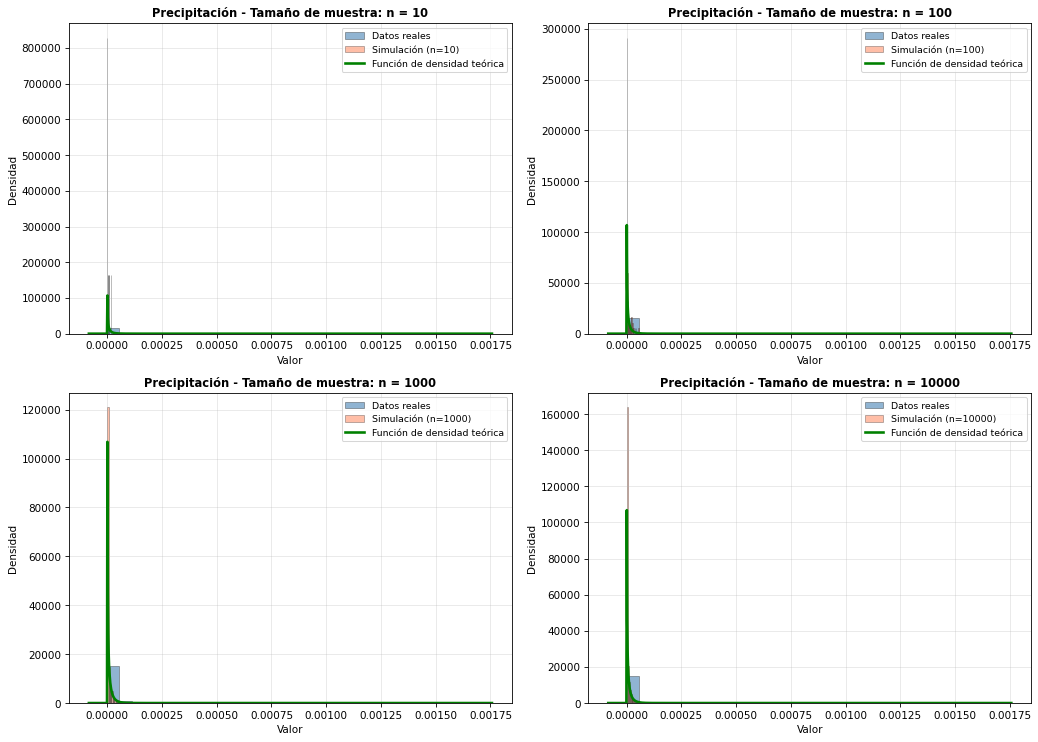

In [17]:
#Precipitación

semilla = 99999
np.random.seed(semilla)


x_real = df_orig_precip["PRECIP_CELDA01"].dropna().values

#Cogemos la Beta del apartado 2.2
params = stats.beta.fit(x_real)

# crea la v.a. "VA" que sigue una beta
a = params[0]
b = params[1]
loc = params[2]
scale = params[3]
VA = stats.beta(a, b, loc=loc, scale=scale)

print("Parámetros precipitación (beta):", params)

x1 = VA.rvs(size=n1)
x2 = VA.rvs(size=n2)
x3 = VA.rvs(size=n3)
x4 = VA.rvs(size=n4)

plot_histogramas(x_real, VA, x1, x2, x3, x4, "Precipitación")

In [ ]:
print("En este apartado se analizan las simulaciones de las variables temperatura, irradiacion y precipitacion en la celda 01, utilizando las distribuciones ajustadas previamente en el apartado 2.2."
      "Para cada variable, se han generado muestras pseudoaleatorias de distintos tamaños (n = 10, 100, 1000 y 10000), comparando en cada caso la distribucion simulada con los datos reales y con la funcion de densidad teorica. \n"
      "De forma general, se observa un comportamiento consistente en las tres variables en funcion del tamaño muestral."
      "Para tamaños pequeños, como n = 10, las distribuciones simuladas presentan una elevada variabilidad y una forma irregular, lo que dificulta su aproximacion tanto a los datos reales como a la densidad teorica. \n"
      "Al aumentar el tamaño de la muestra, como en n = 100 y n = 1000, la distribucion empirica de los datos simulados se vuelve progresivamente mas estable, reduciendo las fluctuaciones aleatorias y aproximandose mejor a la forma general de los datos observados. \n"
      "Para tamaños grandes, como n = 10000, la distribucion simulada converge claramente hacia la distribucion teorica ajustada, mostrando una alta estabilidad y una buena alineacion con la forma global de los datos reales. \n"
      "No obstante, se aprecia que incluso en estos casos existen ciertas diferencias entre la simulacion y los datos observados, lo que muestra que el ajuste de las distribuciones elegidas, aunque sean adecuadas, no capturan completamente la complejidad de las variables reales. \n"
      "En conclusion, el analisis muestra que el aumento del tamaño muestral mejora notablemente la aproximacion de las distribuciones simuladas a la distribucion teorica, reduciendo la variabilidad y aumentando la estabilidad de los resultados. \n"
      "Este comportamiento es coherente con la Ley de los Grandes Numeros, que establece que, a medida que el tamaño de la muestra aumenta, las distribuciones empiricas tienden a aproximarse a la distribución real de la población.")

En este apartado se analizan las simulaciones de las variables temperatura, irradiacion y precipitacion en la celda 01, utilizando las distribuciones ajustadas previamente en el apartado 2.2.Para cada variable, se han generado muestras pseudoaleatorias de distintos tamaños (n = 10, 100, 1000 y 10000), comparando en cada caso la distribucion simulada con los datos reales y con la funcion de densidad teorica. 
De forma general, se observa un comportamiento consistente en las tres variables en funcion del tamaño muestral.Para tamaños pequeños, como n = 10, las distribuciones simuladas presentan una elevada variabilidad y una forma irregular, lo que dificulta su aproximacion tanto a los datos reales como a la densidad teorica. 
Al aumentar el tamaño de la muestra, como en n = 100 y n = 1000, la distribucion empirica de los datos simulados se vuelve progresivamente mas estable, reduciendo las fluctuaciones aleatorias y aproximandose mejor a la forma general de los datos observados. 
Para ta

### Respuesta

#### Observaciones según el tamaño de la muestra:

**Tamaño n = 10:**
- La muestra simulada es muy pequeña y presenta una distribución muy irregular.
- Hay una gran variabilidad y no se aproxima bien a la distribución real ni a la teórica.
- Esto refleja la **alta variabilidad en muestras pequeñas**.

**Tamaño n = 100:**
- La forma general de la distribución simulada comienza a aproximarse a la real.
- Se observa una mejor correspondencia con la función de densidad teórica.
- La irregularidad disminuye significativamente respecto a n = 10.

**Tamaño n = 1000:**
- La distribución simulada se aproxima considerablemente bien a la distribución real.
- La función de densidad teórica se superpone bien con los histogramas.
- Las fluctuaciones aleatorias son menos pronunciadas.

**Tamaño n = 10000:**
- La distribución simulada converge muy claramente a la distribución real.
- Coincidencia casi perfecta con la función de densidad teórica.
- Demostración clara de convergencia a la distribución poblacional.

#### Ley de los Grandes Números:

A medida que aumenta el tamaño de la muestra (n → ∞), **la distribución empírica de los datos simulados converge a la distribución teórica** que caracteriza a la población. Esto ilustra perfectamente el **Teorema del Límite Central** y la **Ley de los Grandes Números**:

- **Con n pequeño (n=10):** Las muestras son muy variables y no representan bien la población.
- **Con n grande (n=10000):** Las muestras son muy estables y convergen a los parámetros poblacionales.

Este comportamiento es fundamental en estadística inferencial: **cuantos más datos observemos, mejor será nuestra estimación de la distribución real de la población**.